# EDA - HotpotQA Dev Distractor Split
Statistics on the full HotpotQA `dev.jsonl` (distractor split): question type, question/answer
length, supporting-fact count, context structure, and prompt token budget.
No LLM calls - embedding-free.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from pathlib import Path

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

K = cfg["retrieval"]["k"]
print("Config loaded. hotpotqa_dev:", cfg["dataset"]["hotpotqa_dev"], f"| k={K}")

Config loaded. hotpotqa_dev: data/hotpotqa/dev.jsonl | k=10


In [2]:
# Read raw file (includes 'type' and 'level' fields stripped by the loader)
dev_path = Path("..") / cfg["dataset"]["hotpotqa_dev"]
with open(dev_path) as f:
    raw = [json.loads(line) for line in f]

df = pd.DataFrame({
    "question":         [e["question"]  for e in raw],
    "answer":           [e["answer"]    for e in raw],
    "type":             [e["type"]      for e in raw],
    "level":            [e["level"]     for e in raw],
    "n_supporting":     [len(e["supporting_facts"]) for e in raw],
    "n_context":        [len(e["context"])           for e in raw],
})
df["q_len"]   = df["question"].str.split().str.len()
df["a_len"]   = df["answer"].str.split().str.len()
df["is_yn"]   = df["answer"].str.lower().isin(["yes", "no"])
# Word count across all context paragraphs (each paragraph = list of sentences)
df["ctx_words"] = [
    sum(len(s.split()) for _, sents in e["context"] for s in sents)
    for e in raw
]

print(f"Total examples      : {len(df):,}")
print(f"Question type       : {dict(Counter(df['type']))}")
print(f"Level               : {dict(Counter(df['level']))}  (distractor split = hard only)")
print(f"Yes/No answers      : {df['is_yn'].sum():,} ({100*df['is_yn'].mean():.1f}%)")
print(f"Free-text answers   : {(~df['is_yn']).sum():,} ({100*(~df['is_yn']).mean():.1f}%)")

Total examples      : 7,405
Question type       : {'comparison': 1487, 'bridge': 5918}
Level               : {'hard': 7405}  (distractor split = hard only)
Yes/No answers      : 458 (6.2%)
Free-text answers   : 6,947 (93.8%)


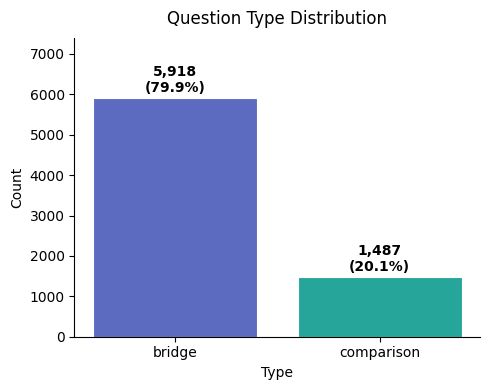

Bridge questions require chaining evidence from two Wikipedia paragraphs.
Comparison questions ask to compare two entities on a shared attribute.


In [3]:
# --- Question type distribution ---
COLORS = {"bridge": "#5C6BC0", "comparison": "#26A69A"}
counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[t] for t in counts.index],
              edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 60, f"{val:,}\n({100*val/len(df):.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Question Type Distribution", fontsize=12, pad=10)
ax.set_xlabel("Type")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/03_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Bridge questions require chaining evidence from two Wikipedia paragraphs.")
print("Comparison questions ask to compare two entities on a shared attribute.")

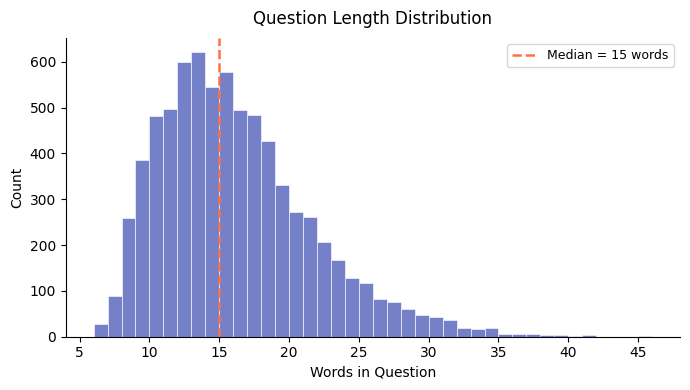

Mean   : 15.7 words
Median : 15 words
Max    : 46 words


In [4]:
# --- Question length distribution ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["q_len"], bins=40, color="#5C6BC0", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(df["q_len"].median(), color="#FF7043", linewidth=1.8, linestyle="--",
           label=f"Median = {df['q_len'].median():.0f} words")
ax.set_title("Question Length Distribution", fontsize=12, pad=10)
ax.set_xlabel("Words in Question")
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/03_question_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean   : {df['q_len'].mean():.1f} words")
print(f"Median : {df['q_len'].median():.0f} words")
print(f"Max    : {df['q_len'].max()} words")

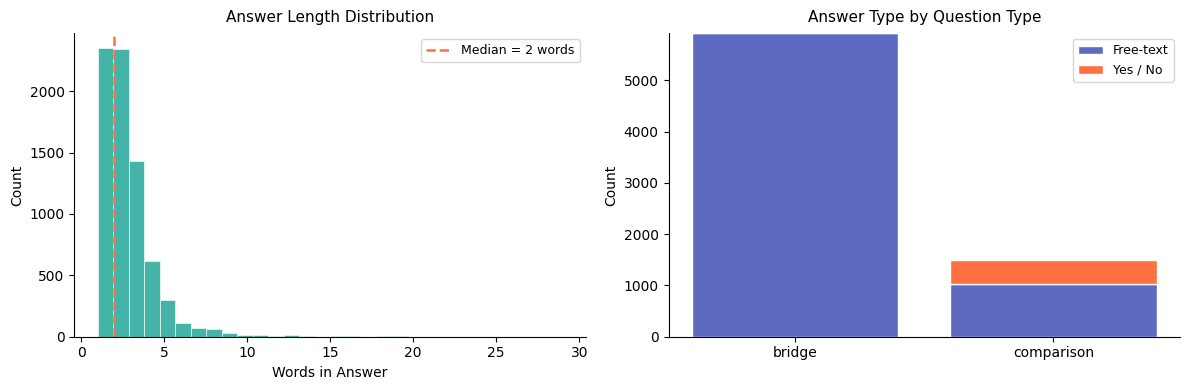

Yes/No answers are predominantly in comparison questions (bridge questions need specific entities).


In [5]:
# --- Answer length + type breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: answer length
ax = axes[0]
ax.hist(df["a_len"], bins=30, color="#26A69A", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(df["a_len"].median(), color="#FF7043", linewidth=1.8, linestyle="--",
           label=f"Median = {df['a_len'].median():.0f} words")
ax.set_title("Answer Length Distribution", fontsize=11, pad=8)
ax.set_xlabel("Words in Answer")
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Right: yes/no vs free-text by question type
ax = axes[1]
type_order = ["bridge", "comparison"]
yn_by_type  = df.groupby("type")["is_yn"].sum().reindex(type_order)
tot_by_type = df.groupby("type")["is_yn"].count().reindex(type_order)
ft_by_type  = tot_by_type - yn_by_type

x = range(len(type_order))
ax.bar(x, ft_by_type.values, label="Free-text", color="#5C6BC0", edgecolor="white")
ax.bar(x, yn_by_type.values, bottom=ft_by_type.values, label="Yes / No", color="#FF7043", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(type_order, fontsize=10)
ax.set_title("Answer Type by Question Type", fontsize=11, pad=8)
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/03_answer_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Yes/No answers are predominantly in comparison questions (bridge questions need specific entities).")

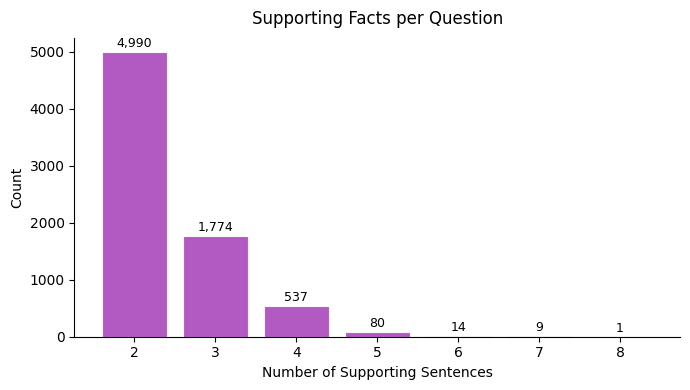

Exactly 2 supporting facts : 67.4% of examples
Multi-hop = both hops must be retrieved for the model to answer correctly.


In [6]:
# --- Supporting facts per question ---
sf_counts = df["n_supporting"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sf_counts.index, sf_counts.values,
       color="#AB47BC", edgecolor="white", linewidth=0.8, alpha=0.9)
for i, (val, cnt) in enumerate(zip(sf_counts.index, sf_counts.values)):
    ax.text(val, cnt + 30, f"{cnt:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Supporting Facts per Question", fontsize=12, pad=10)
ax.set_xlabel("Number of Supporting Sentences")
ax.set_ylabel("Count")
ax.set_xticks(sf_counts.index)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/03_supporting_facts.png", dpi=150, bbox_inches="tight")
plt.show()

pct2 = 100 * (df["n_supporting"] == 2).mean()
print(f"Exactly 2 supporting facts : {pct2:.1f}% of examples")
print("Multi-hop = both hops must be retrieved for the model to answer correctly.")

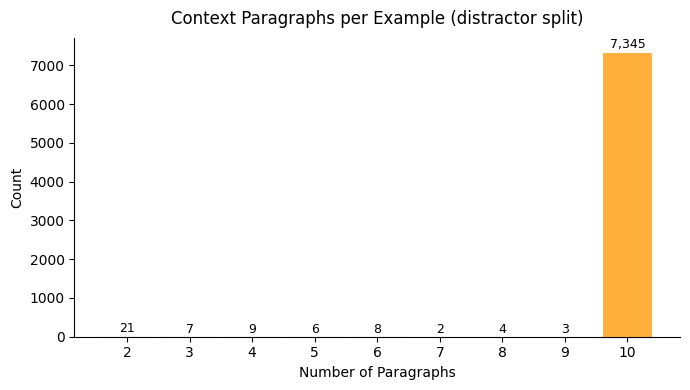

Examples with 10 paragraphs: 99.2% - 2 gold + 8 distractors (distractor split standard)
Distractor challenge: the retriever must identify the 2 gold paragraphs among 10 total.


In [7]:
# --- Context paragraph count ---
# In the distractor split virtually all examples have 10 paragraphs (2 gold + 8 distractors)
ctx_dist = df["n_context"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ctx_dist.index.astype(str), ctx_dist.values,
       color="#FFA726", edgecolor="white", linewidth=0.8, alpha=0.9)
for i, (val, cnt) in enumerate(zip(ctx_dist.index, ctx_dist.values)):
    ax.text(i, cnt + 20, f"{cnt:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Context Paragraphs per Example (distractor split)", fontsize=12, pad=10)
ax.set_xlabel("Number of Paragraphs")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/03_context_count.png", dpi=150, bbox_inches="tight")
plt.show()

pct10 = 100 * (df["n_context"] == 10).mean()
print(f"Examples with 10 paragraphs: {pct10:.1f}% - 2 gold + 8 distractors (distractor split standard)")
print(f"Distractor challenge: the retriever must identify the 2 gold paragraphs among {ctx_dist.idxmax()} total.")

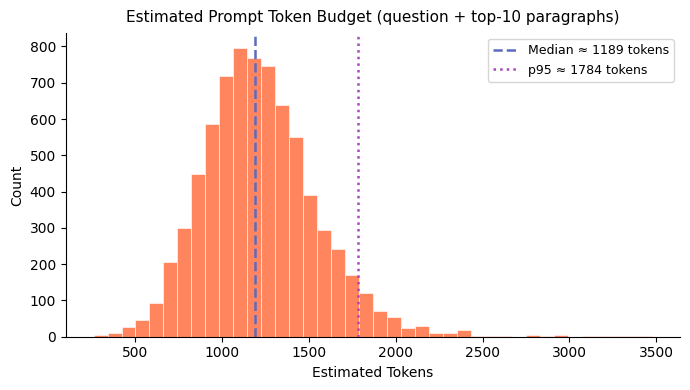

Median budget : ~1189 tokens
p95 budget    : ~1784 tokens
HotpotQA paragraphs are denser than FEVER evidence - multi-hop context is larger per example.


In [8]:
# --- Prompt token budget estimate ---
# 1 token ≈ 0.75 words (standard heuristic)
# Prompt = question + k retrieved paragraphs (each paragraph = all its sentences)
# Approximate by taking mean passage word count across the full context
mean_paragraph_words = df["ctx_words"] / df["n_context"].clip(lower=1)
budget_words  = df["q_len"] + K * mean_paragraph_words
budget_tokens = budget_words / 0.75

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(budget_tokens, bins=40, color="#FF7043", edgecolor="white", linewidth=0.5, alpha=0.85)
p95 = budget_tokens.quantile(0.95)
ax.axvline(budget_tokens.median(), color="#5C6BC0", linewidth=1.8, linestyle="--",
           label=f"Median ≈ {budget_tokens.median():.0f} tokens")
ax.axvline(p95, color="#AB47BC", linewidth=1.8, linestyle=":",
           label=f"p95 ≈ {p95:.0f} tokens")
ax.set_title(f"Estimated Prompt Token Budget (question + top-{K} paragraphs)", fontsize=11, pad=8)
ax.set_xlabel("Estimated Tokens")
ax.set_ylabel("Count")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/03_prompt_budget.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median budget : ~{budget_tokens.median():.0f} tokens")
print(f"p95 budget    : ~{p95:.0f} tokens")
print(f"HotpotQA paragraphs are denser than FEVER evidence - multi-hop context is larger per example.")

In [9]:
# --- Summary table ---
summary = pd.DataFrame({
    "type":       ["bridge", "comparison"],
    "count":      [df[df["type"]==t].shape[0] for t in ["bridge", "comparison"]],
    "pct":        [100 * (df["type"]==t).mean() for t in ["bridge", "comparison"]],
    "mean_q_len": [df[df["type"]==t]["q_len"].mean() for t in ["bridge", "comparison"]],
    "mean_a_len": [df[df["type"]==t]["a_len"].mean() for t in ["bridge", "comparison"]],
    "pct_yn":     [100 * df[df["type"]==t]["is_yn"].mean() for t in ["bridge", "comparison"]],
})
summary.columns = ["Type", "Count", "%", "Mean Q Len", "Mean A Len", "% Yes/No"]

print(f"=== HotpotQA Dev (distractor split) - Summary ===")
print(f"Total examples : {len(df):,}")
print(f"Level          : hard only (distractor split does not include easy/medium)")
print(f"Context        : {(df['n_context']==10).sum():,} / {len(df):,} examples have 10 paragraphs")
print()
print(summary.to_string(index=False, float_format="{:.1f}".format))
print()
print(f"=== Experimental design ===")
print(f"  Gold paragraphs : 2 per question (both hops required)")
print(f"  Distractor pool : global gold pool (all gold passages from other examples in dataset)")
print(f"  Context budget  : k={K} passages ({K}-2 distractors retrieved + 2 injected gold/poisoned)")
print(f"  Poisoning       : exactly 1 supporting fact per example negated by LLM (r=1)")

=== HotpotQA Dev (distractor split) - Summary ===
Total examples : 7,405
Level          : hard only (distractor split does not include easy/medium)
Context        : 7,345 / 7,405 examples have 10 paragraphs

      Type  Count    %  Mean Q Len  Mean A Len  % Yes/No
    bridge   5918 79.9        16.8         2.6       0.0
comparison   1487 20.1        11.5         2.1      30.8

=== Experimental design ===
  Gold paragraphs : 2 per question (both hops required)
  Distractor pool : global gold pool (all gold passages from other examples in dataset)
  Context budget  : k=10 passages (10-2 distractors retrieved + 2 injected gold/poisoned)
  Poisoning       : exactly 1 supporting fact per example negated by LLM (r=1)


## Pre-compute Negations
Generates `data/hotpotqa/dev_poisoned.jsonl` used by `03_smoke_hotpotqa` and `05_experiment_hotpotqa`.
Run once; subsequent executions are instant (LLM responses are disk-cached).

In [10]:
import os
from scripts.precompute_negations import main as precompute

hotpotqa_poisoned = "../" + cfg["dataset"]["hotpotqa_dev_poisoned"]
if os.path.exists(hotpotqa_poisoned):
    print(f"Already available: {hotpotqa_poisoned}")
else:
    n = cfg["evaluation"]["n_examples"]
    print(f"Generating pre-computed negations for HotpotQA (n={n})...")
    precompute(["--config", "../configs/config.yaml", "--dataset", "hotpotqa", "--n", str(n)])
    print("Done.")

Already available: ../data/hotpotqa/dev_poisoned.jsonl
